# Multithreaded CSV Batch Fitting

This notebook shows how to fit many SWV traces from a formatted CSV file. The batch API groups rows into traces, fits each trace with a thread pool, and returns JSON/CSV-friendly results.

In [1]:
from pathlib import Path
import sys
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "peak_extraction").exists():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from peak_extraction.batch import (
    fit_dataframe,
    formatted_csvs_to_dataframe,
    plot_fit_result_from_row,
    plot_signal_over_time,
    results_to_signal_table,
)


## Long-Form CSV DataFrame

Expected columns are `voltage`, `current`, optional `point`, and any metadata columns used for grouping. A common grouping is `file`, `hz`, `num`, `channel`, and `time`.

In [2]:
LONG_FORM_DATA_URL = None  # e.g. "https://.../aswift_long_form_demo.csv"
# LONG_FORM_PATH = Path("data/aswift_long_form_demo.csv")
LONG_FORM_PATH = Path("/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_SELEX/01_Binding Curve/01_Binding Curve_structured_swv.csv")

if LONG_FORM_DATA_URL and not LONG_FORM_PATH.exists():
    LONG_FORM_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(LONG_FORM_DATA_URL, LONG_FORM_PATH)

if LONG_FORM_PATH.exists():
    df = pd.read_csv(LONG_FORM_PATH)
else:
    rng = np.random.default_rng(4)
    volts = np.linspace(-0.2, 0.6, 100)
    rows = []
    for hz in (150, 250):
        for channel in range(2):
            for num in range(8):
                amp = 0.35 + 0.03 * num + 0.04 * channel
                center = 0.18 + 0.015 * channel
                background = 1.0 + 0.08 * volts + 0.0005 * num
                peak = amp * np.exp(-0.5 * ((volts - center) / 0.05) ** 2)
                noise = rng.normal(0.0, 0.004, size=volts.size)
                current = background + peak + noise
                for point, (volt, value) in enumerate(zip(volts, current)):
                    rows.append({
                        "file": f"{hz}hz-{num + 1}.csv",
                        "hz": hz,
                        "num": num,
                        "channel": channel,
                        "time": num * 0.25,
                        "point": point,
                        "voltage": volt,
                        "current": value,
                    })
    df = pd.DataFrame(rows)

df.head()

,folder,file,hz,num,raw_num,channel,time,timestamp,trace_type,point,voltage,current
0,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz-1.csv,100,0,1,0,0.0,2025-05-06 16:43:46,full,0,-0.448009,0.238300
1,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz-1.csv,100,0,1,0,0.0,2025-05-06 16:43:46,full,1,-0.447072,0.215126
2,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz-1.csv,100,0,1,0,0.0,2025-05-06 16:43:46,full,2,-0.446056,0.218130
3,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz-1.csv,100,0,1,0,0.0,2025-05-06 16:43:46,full,3,-0.445041,0.208939
4,/Users/Max_1/Soh Lab/echem/20250506_ATP_npAu_S...,100hz-1.csv,100,0,1,0,0.0,2025-05-06 16:43:46,full,4,-0.444103,0.195337


In [3]:
results = fit_dataframe(
    df,
    method="aswift",  # or "poly_linear"
    group_cols=["file", "hz", "num", "channel", "time"],
    n_workers=4,
)

signal_table = results_to_signal_table(
    results,
    calibration_lower_idx=0,
    calibration_upper_idx=2,
)

results[["hz", "num", "channel", "peak", "peak_voltage", "success"]].head()

,hz,num,channel,peak,peak_voltage,success
0,100,0,0,0.781164,-0.233789,True
1,100,9,0,0.821616,-0.237774,True
2,100,10,0,0.806809,-0.238790,True
3,100,11,0,0.818599,-0.238790,True
4,100,12,0,0.823743,-0.239727,True


## Optional Streamlit Viewer

Save the structured batch results and launch the lightweight Streamlit viewer from a terminal. The app sorts and filters by channel, frequency, and sample order.

In [4]:
OUTPUT_DIR = Path("outputs/structured_csv_demo")
RESULTS_JSON = OUTPUT_DIR / "structured_fit_results.json"
SIGNAL_TABLE_CSV = OUTPUT_DIR / "structured_signal_table.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results.to_json(RESULTS_JSON, orient="records", indent=2)
signal_table.to_csv(SIGNAL_TABLE_CSV, index=False)

import socket
import subprocess
import time


def available_port(preferred=8501):
    for port in (preferred, 0):
        with socket.socket() as sock:
            try:
                sock.bind(("localhost", port))
            except OSError:
                continue
            return sock.getsockname()[1]
    raise RuntimeError("Could not find an available Streamlit port.")


viewer_script = (repo_root / "analysis" / "structured_results_viewer.py").resolve()
results_json = RESULTS_JSON.resolve()
port = available_port()
viewer_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "--server.headless=true",
        f"--server.port={port}",
        str(viewer_script),
        "--",
        str(results_json),
    ],
    cwd=repo_root,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
)
time.sleep(1)
if viewer_process.poll() is not None:
    raise RuntimeError("Streamlit failed to start. Confirm streamlit is installed in this notebook kernel.")
print(f"Saved results to {results_json}")
print(f"Streamlit viewer running at http://localhost:{port}")

Saved results to /Users/Max_1/PycharmProjects/aswift/examples/outputs/structured_csv_demo/structured_fit_results.json
Streamlit viewer running at http://localhost:8501


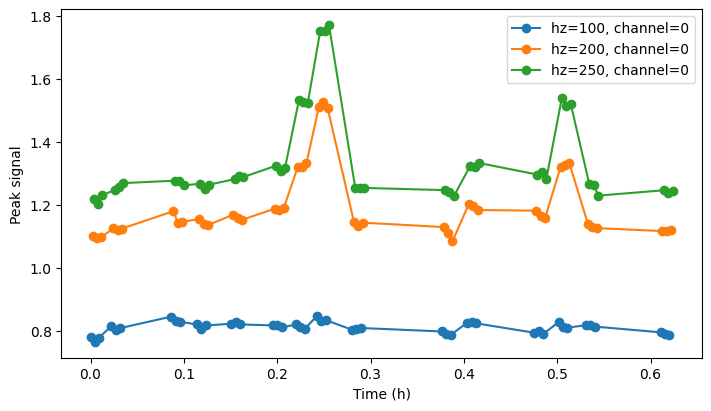

,num,time,signal-hz100-channel0,gain-hz100-channel0,signal-hz200-channel0,gain-hz200-channel0,signal-hz250-channel0,gain-hz250-channel0
0,0,0.000000,0.781164,0.006768,1.101416,0.002291,1.220922,0.001844
1,1,0.004722,0.766332,-0.012348,1.096567,-0.002121,1.203532,-0.012426
2,2,0.009444,0.780242,0.005580,1.098712,-0.000170,1.231571,0.010582
3,3,0.022222,0.816927,0.052860,1.126733,0.025329,1.248705,0.024641
4,4,0.026944,0.804337,0.036633,1.120045,0.019243,1.257922,0.032205


In [5]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
plot_signal_over_time(results, ax=ax)
plt.show()

signal_table.head()